Authors:
- Iria Janeiro Pazos.
- Laura González Lemos.

In [19]:
import random
random.seed(1234)

In [20]:
# Download dataset
import tensorflow as tf
import tensorflow_datasets as tfds

raw_train_data, train_info = tfds.load('stl10', split='train', as_supervised=True, with_info=True) # tuple (image, label)
raw_test_data, test_info = tfds.load('stl10', split='test', as_supervised=True, with_info=True) # tuple (image, label)

Number of classes: 10
Classes names: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

Features shape: (96, 96, 3)
Features dtype: <dtype: 'uint8'>


,image,label
0,,1 (bird)
1,,0 (airplane)
2,,8 (ship)
3,,3 (cat)

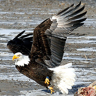
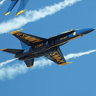
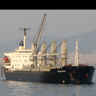
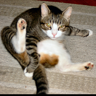

In [21]:
# Check train data
print('Number of classes:', train_info.features["label"].num_classes)
print('Classes names:', train_info.features["label"].names)
print()
print('Features shape:', train_info.features["image"].shape)
print('Features dtype:', train_info.features["image"].dtype)


tfds.as_dataframe(raw_train_data.take(4), train_info)


Number of classes: 10
Classes names: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

Features shape: (96, 96, 3)
Features dtype: <dtype: 'uint8'>


,image,label
0,,9 (truck)
1,,3 (cat)
2,,3 (cat)
3,,1 (bird)

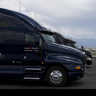
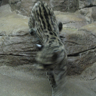
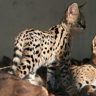
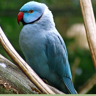

In [22]:
# Check test data
print('Number of classes:', test_info.features["label"].num_classes)
print('Classes names:', test_info.features["label"].names)
print()
print('Features shape:', test_info.features["image"].shape)
print('Features dtype:', test_info.features["image"].dtype)


tfds.as_dataframe(raw_test_data.take(4), test_info)

# Data Preprocessing

The first step in the project is to preprocess the data. We perform the following transformations:
- Image size normalization: We resize all images to a common size to ensure consistency in the input data.
- One hot encoding: We convert categorical labels into a binary format that can be used by machine learning algorithms.

In [23]:
# Preprocessing

def preprocess(image, label, train_info=train_info):
    # Rescale the image (normalize)
    image = tf.cast(image, tf.float32) / 255.0

    # One-hot encode the labels
    num_classes = train_info.features["label"].num_classes
    label = tf.one_hot(label, depth=num_classes)

    return image, label

prep_train_data = raw_train_data.map(preprocess)
test_data = raw_test_data.map(preprocess)

Secondly, we split the dataset into training and validation sets (80% training, 20% validation). A test split is not needed as the dataset already provides a seperate test set.

In [24]:
# Train-Validation split (80-20)
prep_train_data = prep_train_data.shuffle(1000, reshuffle_each_iteration=False) # Shuffle the dataset before splitting

num_samples = train_info.splits['train'].num_examples
train_size = int(0.8 * num_samples)

train_data = prep_train_data.take(train_size)
val_data = prep_train_data.skip(train_size)

In [25]:
BATCH_SIZE = 32

# 1. Batch the training data and use prefetch for speed
# We shuffle again here to ensure randomness within the batches
train_data = train_data.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 2. Batch the validation data
val_data = val_data.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 3. Batch the test data
test_data = test_data.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Helper Functions

In [26]:
def train_model(model, train_data, val_data, epochs=25, learning_rate=0.001, patience=5):

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), 
        loss='categorical_crossentropy', 
        metrics=['accuracy']
    )

    # Callbacks for tuning
    callbacks = [
        tf.keras.callbacks.EarlyStopping(patience=patience, restore_best_weights=True)
    ]
    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=epochs,
        callbacks=callbacks
    )
    return history

    

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, model_name="Model"):
    """
    Plots the training and validation accuracy and loss.
    """
    # Extract metrics from the history object [cite: 230]
    acc = history.history.get('accuracy')
    val_acc = history.history.get('val_accuracy')
    loss = history.history.get('loss')
    val_loss = history.history.get('val_loss')
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Plot 1: Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='x')
    plt.title(f'{model_name}: Accuracy Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.ylim(0, 1)  # Set y-axis limits for better visualization

    # Plot 2: Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', marker='x')
    plt.title(f'{model_name}: Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Baseline Model

- Low accuracy.
- Fast overfitting.

In [28]:
from tensorflow.keras import layers, models

def build_baseline_model(input_shape, num_classes):
    model = models.Sequential([
        # 1. First Convolutional Block
        layers.InputLayer(input_shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # 2. Second Convolutional Block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # 3. Third Convolutional Block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # 4. Flatten and Dense Layers for Classification
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

In [29]:
img_shape = train_info.features['image'].shape
num_classes = train_info.features['label'].num_classes

baseline = build_baseline_model(img_shape, num_classes)
baseline.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 646,858 (2.47 MB)

 Trainable params: 646,858 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.2116 - loss: 2.0945 - val_accuracy: 0.3710 - val_loss: 1.6747
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.4271 - loss: 1.5559 - val_accuracy: 0.4670 - val_loss: 1.4431
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.5302 - loss: 1.3251 - val_accuracy: 0.5210 - val_loss: 1.3463
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.5846 - loss: 1.1432 - val_accuracy: 0.5000 - val_loss: 1.4371
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.6757 - loss: 0.8841 - val_accuracy: 0.5220 - val_loss: 1.3739
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.7633 - loss: 0.6987 - val_accuracy: 0.5450 - val_loss: 1.4233
Epoch 7/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.8120 - loss: 0.5474 - val_accuracy: 0.5490 - val_loss: 1.5583
Epoch 8/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.8589 - loss: 0.3904 - val_a

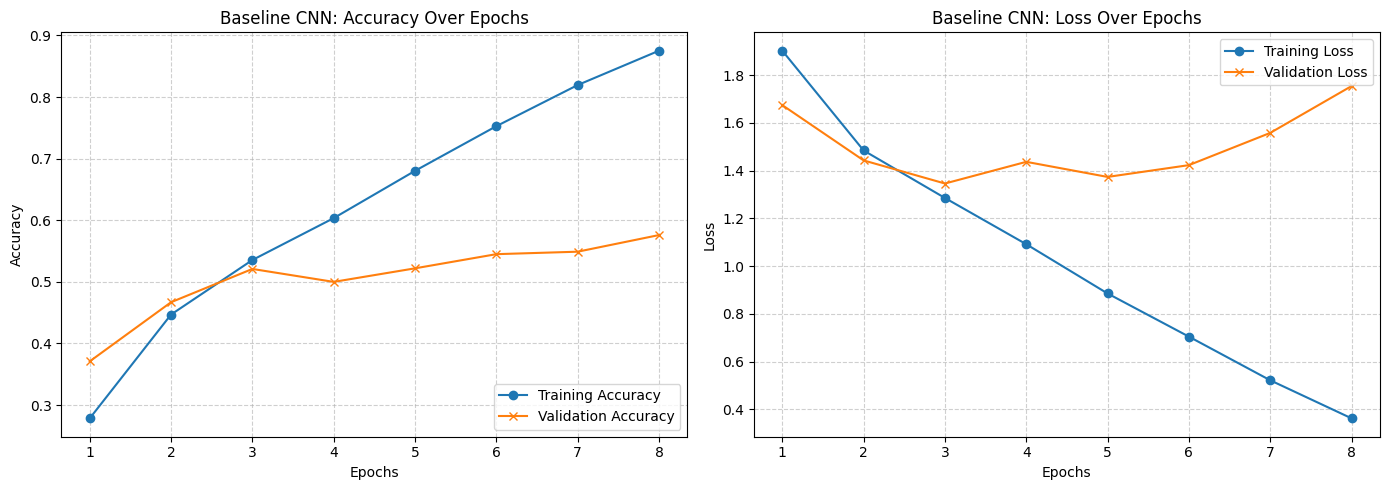

In [ ]:
history = train_model(baseline, train_data, val_data)
plot_history(history, model_name="Baseline CNN")

baseline.save("CustomModels/baseline_cnn.keras")
print("Baseline model saved to 'CustomModels/baseline_cnn.keras'")

In [ ]:
try:
    baseline = tf.keras.models.load_model("CustomModels/baseline_cnn.keras")
    print("Baseline model loaded successfully from 'CustomModels/baseline_cnn.keras'")
except Exception as e:
    print(f"Error loading baseline model: {e}")
    exit(1)

test_loss, test_accuracy = baseline.evaluate(test_data)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.4999 - loss: 1.3632
Test Accuracy: 51.05%
Test Loss: 1.3592


# Custom CNN

Added Droupout

In [32]:
from tensorflow.keras import layers, models

def dropout_model():
    input_shape = train_info.features['image'].shape
    num_classes = train_info.features['label'].num_classes

# Added Dropout

    model = models.Sequential([
    # 1. First Convolutional Block
    layers.InputLayer(input_shape=input_shape),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    # 2. Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    # 3. Third Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    # 4. Flatten and Dense Layers for Classification
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])
    
    return model



In [33]:
model = dropout_model()

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 646,858 (2.47 MB)

 Trainable params: 646,858 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

-----Training with learning rate: 0.001-----
Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - accuracy: 0.1619 - loss: 2.2010 - val_accuracy: 0.3710 - val_loss: 1.7516
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.2956 - loss: 1.8172 - val_accuracy: 0.4110 - val_loss: 1.5650
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.3457 - loss: 1.6715 - val_accuracy: 0.4330 - val_loss: 1.4854
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.3879 - loss: 1.5509 - val_accuracy: 0.4530 - val_loss: 1.4339
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.4102 - loss: 1.4967 - val_accuracy: 0.4910 - val_loss: 1.3633
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.4608 - loss: 1.3549 - val_accuracy: 0.5090 - val_loss: 1.3087
Epoch 7/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.4895 - loss: 1.3517 - val_accuracy: 0.4960 - val_loss: 1.2924
Epoch 8/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/ste

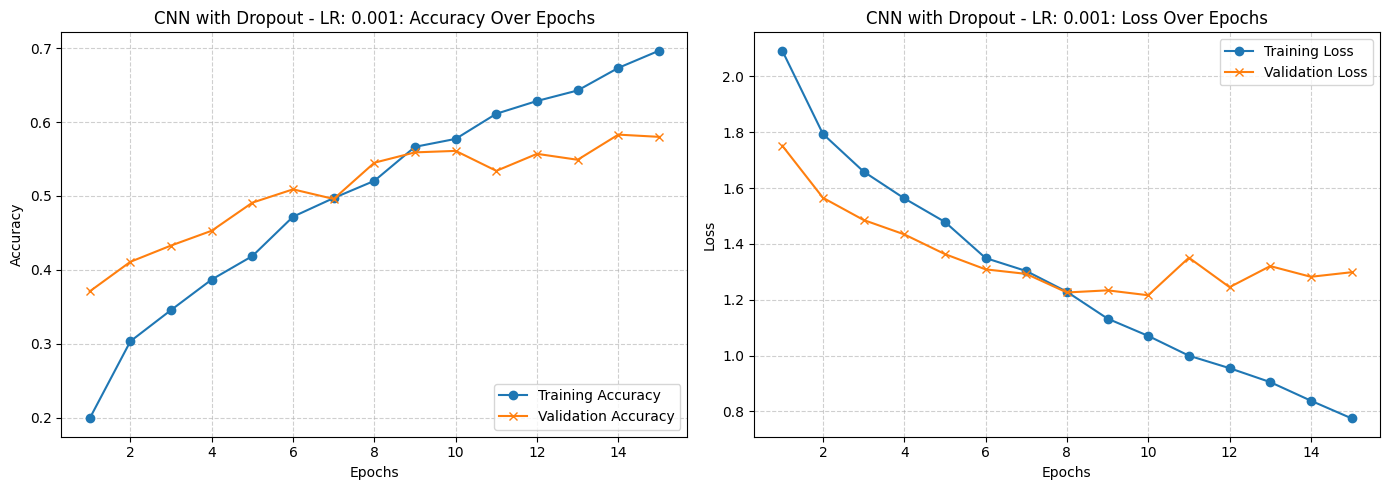

-----Training with learning rate: 0.0005-----
Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.1789 - loss: 2.1948 - val_accuracy: 0.3520 - val_loss: 1.7102
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.3386 - loss: 1.7849 - val_accuracy: 0.4410 - val_loss: 1.5323
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.3641 - loss: 1.6381 - val_accuracy: 0.4500 - val_loss: 1.4418
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.4242 - loss: 1.5158 - val_accuracy: 0.5080 - val_loss: 1.3416
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.4769 - loss: 1.3657 - val_accuracy: 0.5300 - val_loss: 1.2998
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.5338 - loss: 1.2733 - val_accuracy: 0.5250 - val_loss: 1.2719
Epoch 7/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.5618 - loss: 1.1964 - val_accuracy: 0.5260 - val_loss: 1.2907
Epoch 8/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/st

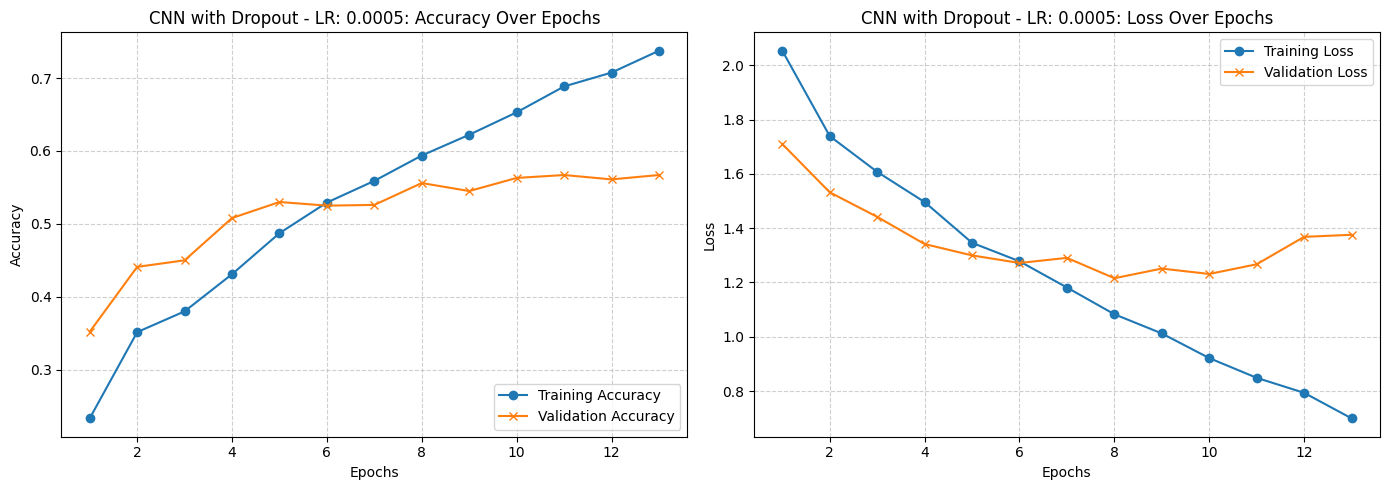

-----Training with learning rate: 0.0001-----
Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.1823 - loss: 2.1708 - val_accuracy: 0.3430 - val_loss: 1.7012
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.3285 - loss: 1.7834 - val_accuracy: 0.4240 - val_loss: 1.5508
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.3817 - loss: 1.6534 - val_accuracy: 0.4740 - val_loss: 1.4467
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.4061 - loss: 1.5434 - val_accuracy: 0.5120 - val_loss: 1.3395
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.4596 - loss: 1.4164 - val_accuracy: 0.5180 - val_loss: 1.3471
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.4962 - loss: 1.3383 - val_accuracy: 0.5220 - val_loss: 1.2896
Epoch 7/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.5202 - loss: 1.2592 - val_accuracy: 0.5530 - val_loss: 1.2595
Epoch 8/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/s

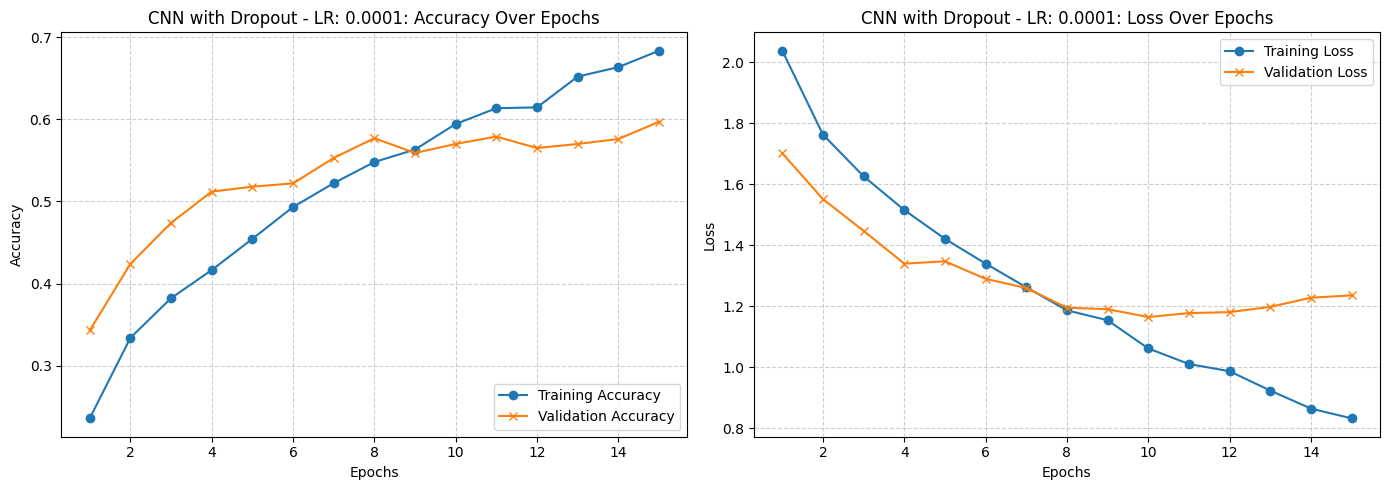

In [34]:
learning_rates = [0.001, 0.0005, 0.0001]

for lr in learning_rates:
    print(f"-----Training with learning rate: {lr}-----")
    model = dropout_model()
    history = train_model(model, train_data, val_data)
    plot_history(history, model_name=f"CNN with Dropout - LR: {lr}")

In [35]:
test_loss, test_accuracy = model.evaluate(test_data)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

  9/250 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5600 - loss: 1.1910

250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5665 - loss: 1.2114
Test Accuracy: 57.39%
Test Loss: 1.1991


Data Augmentation

In [36]:
from tensorflow.keras import layers, models

def augmen_model():
    input_shape = train_info.features['image'].shape
    num_classes = train_info.features['label'].num_classes

    model = models.Sequential([
    # 1. First Convolutional Block
    layers.InputLayer(input_shape=input_shape),
    # Data Augmentation
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    # 2. Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    # 3. Third Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    # 4. Flatten and Dense Layers for Classification
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])
    
    return model

model = augmen_model()

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 96, 96, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 646,858 (2.47 MB)

 Trainable params: 646,858 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

-----Training with learning rate: 0.001-----
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.1616 - loss: 2.2027 - val_accuracy: 0.2910 - val_loss: 1.8751
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.2762 - loss: 1.9042 - val_accuracy: 0.3550 - val_loss: 1.6555
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.3346 - loss: 1.7374 - val_accuracy: 0.3760 - val_loss: 1.5843
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.3625 - loss: 1.6681 - val_accuracy: 0.4010 - val_loss: 1.5388
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.3688 - loss: 1.6272 - val_accuracy: 0.4460 - val_loss: 1.4606
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.3910 - loss: 1.5721 - val_accuracy: 0.4430 - val_loss: 1.4968
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.3991 - loss: 1.5514 - val_accuracy: 0.4530 - val_loss: 1.4368
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s

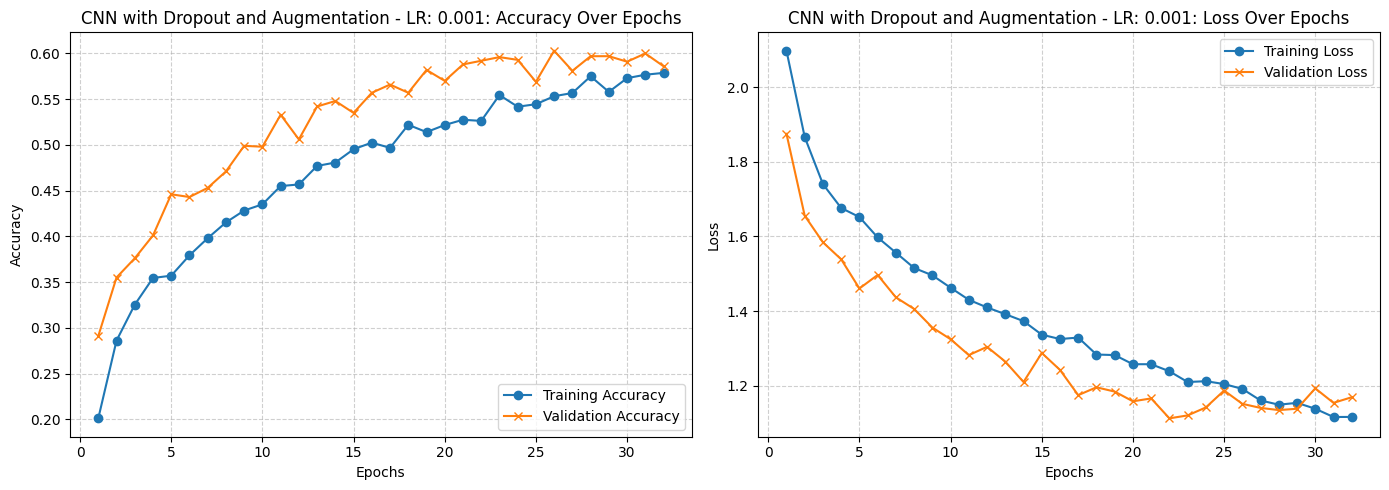

-----Training with learning rate: 0.0005-----
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.1655 - loss: 2.2250 - val_accuracy: 0.3320 - val_loss: 1.8156
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.2716 - loss: 1.9040 - val_accuracy: 0.3610 - val_loss: 1.6661
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.3179 - loss: 1.8047 - val_accuracy: 0.4330 - val_loss: 1.6087
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.3477 - loss: 1.7068 - val_accuracy: 0.4410 - val_loss: 1.5456
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.3798 - loss: 1.6273 - val_accuracy: 0.4500 - val_loss: 1.4628
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.3824 - loss: 1.6130 - val_accuracy: 0.4660 - val_loss: 1.4382
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.4164 - loss: 1.5664 - val_accuracy: 0.4920 - val_loss: 1.3845
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 

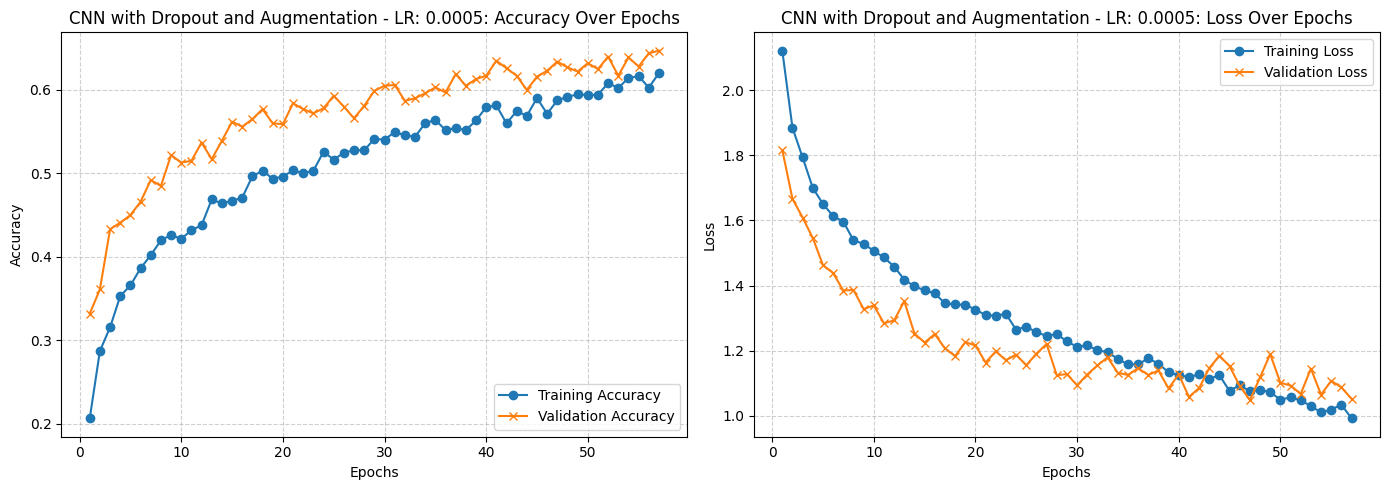

-----Training with learning rate: 0.0001-----
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.1189 - loss: 2.2839 - val_accuracy: 0.2920 - val_loss: 2.1610
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.2195 - loss: 2.1169 - val_accuracy: 0.3270 - val_loss: 1.9014
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.2768 - loss: 1.9448 - val_accuracy: 0.3680 - val_loss: 1.7604
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.2905 - loss: 1.8906 - val_accuracy: 0.3970 - val_loss: 1.7283
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.3077 - loss: 1.8338 - val_accuracy: 0.4050 - val_loss: 1.6700
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.3217 - loss: 1.8161 - val_accuracy: 0.3910 - val_loss: 1.6627
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.3435 - loss: 1.7553 - val_accuracy: 0.4240 - val_loss: 1.6057
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 9

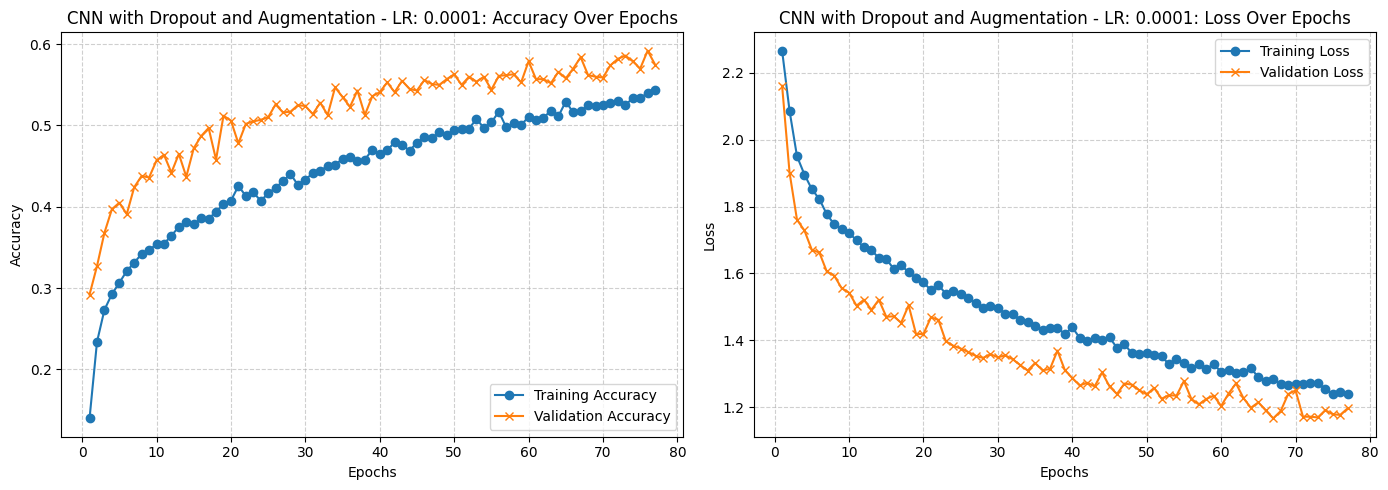

In [37]:
learning_rates = [0.001, 0.0005, 0.0001]

for lr in learning_rates:
    print(f"-----Training with learning rate: {lr}-----")
    model = augmen_model()
    history = train_model(model, train_data, val_data, epochs=100, learning_rate=lr, patience=10)
    plot_history(history, model_name=f"CNN with Dropout and Augmentation - LR: {lr}")

In [38]:
test_loss, test_accuracy = model.evaluate(test_data)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.5724 - loss: 1.1701
Test Accuracy: 57.95%
Test Loss: 1.1589


# RestNet

In [39]:
from tensorflow.keras import layers, models, regularizers

def residual_block(x, filters, stride=1):
    shortcut = x
    
    # First convolution in the block
    x = layers.Conv2D(filters, (3, 3), strides=stride, padding='same', 
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # Second convolution
    x = layers.Conv2D(filters, (3, 3), strides=1, padding='same', 
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    
    # Adjust shortcut if dimensions changed
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), strides=stride, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
        
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

In [40]:
from tensorflow.keras import layers, models, regularizers


input_shape = train_info.features['image'].shape
num_classes = train_info.features['label'].num_classes

inputs = layers.Input(shape=input_shape)
    
# 1. Stronger Data Augmentation
x = layers.RandomFlip("horizontal")(inputs)
x = layers.RandomRotation(0.15)(x) # Slightly increased rotation
x = layers.RandomZoom(0.1)(x) # Added zoom to increase variety
    
# 2. Initial Feature Extraction
x = layers.Conv2D(32, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
    
# 3. Stacked Residual Blocks (Increasing Complexity)
x = residual_block(x, 32)
x = residual_block(x, 64, stride=2) # Downsample to 48x48 
x = residual_block(x, 64)
x = layers.Dropout(0.3)(x) # Intermediate dropout 
    
x = residual_block(x, 128, stride=2) # Downsample to 24x24 
x = residual_block(x, 128)
    
# 4. Global Average Pooling (Crucial for STL-10)
# This replaces the Flatten layer to reduce overfitting 
x = layers.GlobalAveragePooling2D()(x)
    
# 5. Final Classification Head
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
    
model = models.Model(inputs, outputs)



In [ ]:
history = train_model(model, train_data, val_data, epochs=50, learning_rate=0.0005, patience=10)
plot_history(history, model_name="ResNet")

TypeError: train_model() got an unexpected keyword argument 'model_name'

In [ ]:
test_loss, test_accuracy = model.evaluate(test_data)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.5907 - loss: 1.2156
Test Accuracy: 59.01%
Test Loss: 1.2121
